# PowerCo Customer Churn Analysis
**Objective:** Identify the drivers of customer attrition for PowerCo. 
This analysis explores client demographics, pricing trends, and product adoption to understand why customers choose to churn.


In [2]:
import pandas as pd

# Load the datasets
client_df = pd.read_csv('client_data.csv')
price_df = pd.read_csv('price_data.csv')

# Inspect the data and columns
display(client_df.head())
display(price_df.head())

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,t,0.00,25.44,25.44,2,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,f,0.00,16.38,16.38,1,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,f,0.00,28.60,28.60,1,6.60,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,...,f,0.00,30.22,30.22,1,25.46,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.200,0
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,...,f,52.32,44.91,44.91,1,47.98,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,19.800,0


,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.0,0.0,44.266931,0.0,0.0
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.0,0.0,44.266931,0.0,0.0
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.0,0.0,44.266931,0.0,0.0
3,038af19179925da21a25619c5a24b745,2015-04-01,0.149626,0.0,0.0,44.266931,0.0,0.0
4,038af19179925da21a25619c5a24b745,2015-05-01,0.149626,0.0,0.0,44.266931,0.0,0.0


### 1. Data Loading and Integration
We begin by loading the client and price datasets. To perform a comprehensive analysis, we merge these datasets on the unique customer identifier (`id`). This allows us to link pricing history to specific customer behavior.

In [3]:
# Merge the datasets on the 'id' column
# We use a 'left' join to keep all our clients, even if some price data is missing
merged_df = pd.merge(client_df, price_df, on='id', how='left')

# Check how big our new combined dataset is
print(f"Merged Data Shape: {merged_df.shape}")

# Take a peek at the combined data
display(merged_df.head())

Merged Data Shape: (175149, 33)


,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,origin_up,pow_max,churn,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.0,...,lxidpiddsbxsbosboudacockeimpuepw,43.648,1,2015-01-01,0.125976,0.103395,0.071536,40.565969,24.339581,16.226389
1,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.0,...,lxidpiddsbxsbosboudacockeimpuepw,43.648,1,2015-02-01,0.125976,0.103395,0.071536,40.565969,24.339581,16.226389
2,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.0,...,lxidpiddsbxsbosboudacockeimpuepw,43.648,1,2015-03-01,0.125976,0.103395,0.071536,40.565973,24.339578,16.226383
3,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.0,...,lxidpiddsbxsbosboudacockeimpuepw,43.648,1,2015-04-01,0.125976,0.103395,0.071536,40.565973,24.339578,16.226383
4,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.0,...,lxidpiddsbxsbosboudacockeimpuepw,43.648,1,2015-05-01,0.125976,0.103395,0.071536,40.565973,24.339578,16.226383


### 2. Data Quality Assessment
To ensure our machine learning model performs reliably, we check for missing values. Clean, complete data is essential to avoid introducing noise or bias into our predictions.

In [5]:
# Check total missing values per column
missing_values = merged_df.isnull().sum()

# Let's filter to only show columns that actually have missing data
missing_values = missing_values[missing_values > 0]

# Calculate the percentage of missing data for context
missing_percentage = (missing_values / len(merged_df)) * 100

# Combine them into a nice, readable DataFrame
missing_info = pd.DataFrame({
    'Total Missing': missing_values, 
    'Percentage (%)': missing_percentage
}).sort_values(by='Percentage (%)', ascending=False)

display(missing_info)

,Total Missing,Percentage (%)


In [6]:
# 1. Set our threshold: drop columns missing more than 75% of their data
threshold = 75
cols_to_drop = missing_info[missing_info['Percentage (%)'] > threshold].index
cleaned_df = merged_df.drop(columns=cols_to_drop)

print(f"Dropped columns: {list(cols_to_drop)}")

# 2. For the remaining minor missing values, drop those specific rows
cleaned_df = cleaned_df.dropna()

# 3. Verify our new, pristine dataset
print(f"Original Data Shape: {merged_df.shape}")
print(f"Cleaned Data Shape: {cleaned_df.shape}")

# Double-check that all missing values are gone
print(f"Remaining Missing Values: {cleaned_df.isnull().sum().sum()}")

Dropped columns: []
Original Data Shape: (175149, 33)
Cleaned Data Shape: (175149, 33)
Remaining Missing Values: 0


### 3. Exploratory Data Analysis (EDA)
We now investigate the distribution of our target variable, `churn`. 
- Understanding the ratio of customers who stayed vs. left is crucial, as this dataset is highly imbalanced (a common challenge in churn prediction).

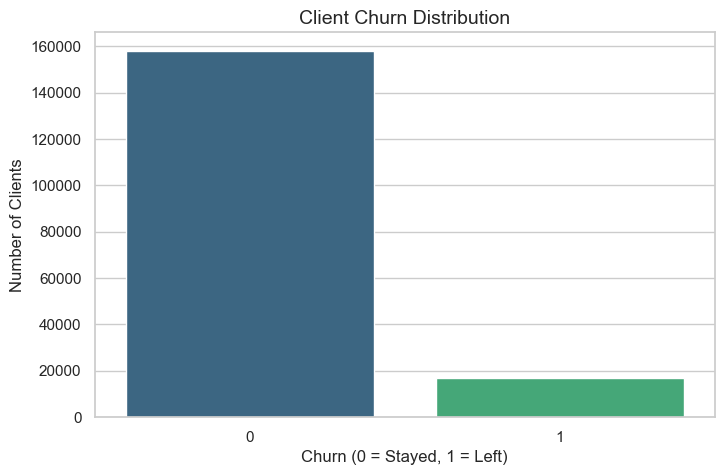

Overall Churn Rate: 9.71%


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for prettier plots
sns.set_theme(style="whitegrid")

# Create a bar plot of the churn counts
plt.figure(figsize=(8, 5))

# UPDATED: Added hue='churn' and legend=False to comply with modern Seaborn
sns.countplot(data=cleaned_df, x='churn', hue='churn', palette='viridis', legend=False)

# Add some helpful labels
plt.title('Client Churn Distribution', fontsize=14)
plt.xlabel('Churn (0 = Stayed, 1 = Left)', fontsize=12)
plt.ylabel('Number of Clients', fontsize=12)

plt.show()

# Print the exact percentage
churn_rate = cleaned_df['churn'].mean() * 100
print(f"Overall Churn Rate: {churn_rate:.2f}%")

### 4. Feature Hypothesis Testing
We test specific business hypotheses to identify features that correlate with churn:
- **Gross Margin:** Do higher-profit customers churn at different rates?
- **Bundling (Gas):** Does offering multiple products ("sticky" services) reduce the likelihood of a customer leaving?
- **Tenure:** Is there a specific point in time (a "tenure cliff") where customers are most likely to leave?

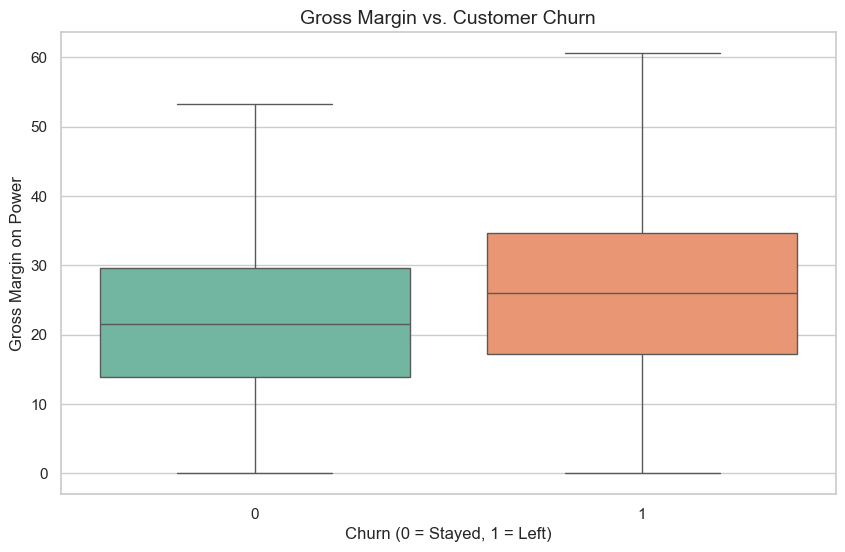

In [12]:
# Create a boxplot to compare numerical data between our two groups
plt.figure(figsize=(10, 6))

# Updated with hue='churn' and legend=False for modern Seaborn
sns.boxplot(data=cleaned_df, x='churn', y='margin_gross_pow_ele', hue='churn', palette='Set2', legend=False, showfliers=False)

plt.title('Gross Margin vs. Customer Churn', fontsize=14)
plt.xlabel('Churn (0 = Stayed, 1 = Left)', fontsize=12)
plt.ylabel('Gross Margin on Power', fontsize=12)

plt.show()

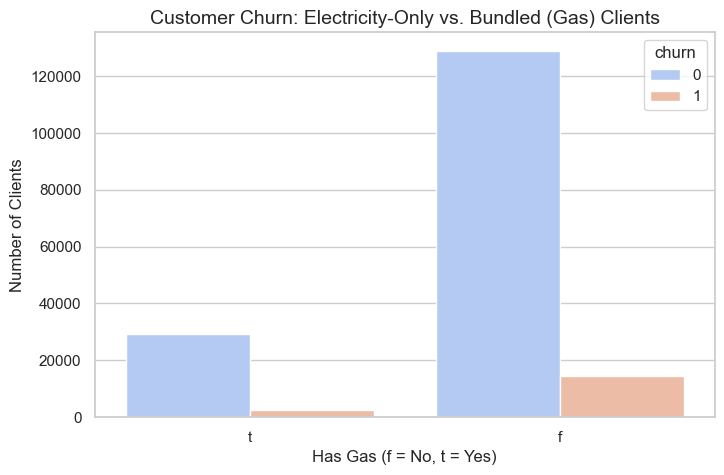

Churn Rate by Gas Status:
has_gas
f    10.043665
t     8.192544
Name: churn, dtype: float64


In [13]:
# Create a grouped bar chart for a categorical variable
plt.figure(figsize=(8, 5))

# We use countplot again, but 'hue' splits the bars by who stayed and left
sns.countplot(data=cleaned_df, x='has_gas', hue='churn', palette='coolwarm')

plt.title('Customer Churn: Electricity-Only vs. Bundled (Gas) Clients', fontsize=14)
plt.xlabel('Has Gas (f = No, t = Yes)', fontsize=12)
plt.ylabel('Number of Clients', fontsize=12)

plt.show()

# Let's calculate the exact churn rate for each group to be sure
gas_churn_rates = cleaned_df.groupby('has_gas')['churn'].mean() * 100
print("Churn Rate by Gas Status:")
print(gas_churn_rates)

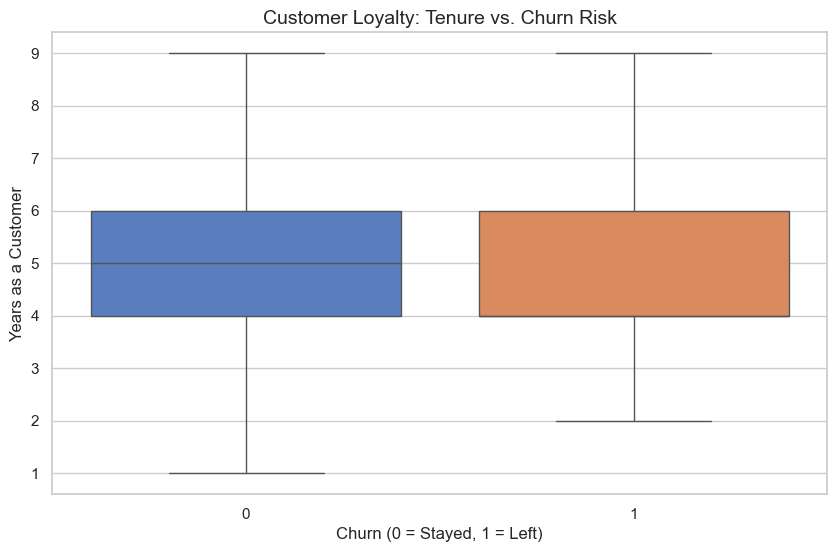

Average Years as a Customer:
Stayed (0): 5.04 years
Left (1): 4.63 years


In [14]:
# Create a boxplot to compare tenure (years as a customer) against churn
plt.figure(figsize=(10, 6))

# We use the 'num_years_antig' column here
sns.boxplot(data=cleaned_df, x='churn', y='num_years_antig', hue='churn', palette='muted', legend=False, showfliers=False)

plt.title('Customer Loyalty: Tenure vs. Churn Risk', fontsize=14)
plt.xlabel('Churn (0 = Stayed, 1 = Left)', fontsize=12)
plt.ylabel('Years as a Customer', fontsize=12)

plt.show()

# Let's also print the average years for both groups just to be precise
average_tenure = cleaned_df.groupby('churn')['num_years_antig'].mean()
print("Average Years as a Customer:")
print(f"Stayed (0): {average_tenure[0]:.2f} years")
print(f"Left (1): {average_tenure[1]:.2f} years")